# Hysteresis figure accross Arnolds Tongue figure

In [13]:
import time
from typing import List
import itertools
import numpy as np
from tqdm.auto import tqdm
from scipy.integrate import odeint
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'
import torchode
import pickle

from sklearn.cluster import KMeans
from scipy.optimize import root as sp_root
from scipy.optimize import fsolve
import warnings

from ftnode.node import (FeluSigmoidMLP, GeluSigmoidMLP, FTNODE)

import torch
import torch.nn as nn
device='cpu'

from ftnode.utils import set_global_seed

seed = 1234
set_global_seed(seed = seed)

[Seed] Deterministic mode enabled (may reduce speed).


## Load trained model

In [14]:
model_path = "../best_model-20-20-20.pth"

f = FeluSigmoidMLP(
    dims = [2,20,20,20,2],
    lower_bound = -10,
    upper_bound =-0.1
)

g = GeluSigmoidMLP(
    dims = [6,20,20,20,2],
    lower_bound = -1,
    upper_bound = 8
)

model = FTNODE(f,g)

model.load_state_dict(torch.load(model_path))
model.eval() #

f = model.f
g = model.g

f.eval()
g.eval()


GeluSigmoidMLP(
  (activation): SiLU()
  (network): MLP(
    (activation): SiLU()
    (layers): ModuleList(
      (0): Linear(in_features=6, out_features=20, bias=True)
      (1-2): 2 x Linear(in_features=20, out_features=20, bias=True)
      (3): Linear(in_features=20, out_features=2, bias=True)
    )
  )
)

In [15]:
# warnings.filterwarnings('ignore')
def composite_eq(x1, alpha1, alpha2, n):
    """
    Symmetric cooperativity (beta = gamma = n).
    Solves x1 = f(g(x1)).
    """
    x1_safe = np.abs(x1)
    x2 = alpha2 / (1 + x1_safe**n)
    val = alpha1 / (1 + x2**n)
    return x1_safe - val


In [16]:
coop_levels = [2.5,3.75, 5.0] 
colors = ['blue', 'green','purple']
labels = [
    'Weak ($\\beta=\\gamma=2.5$)',
    'Medium ($\\beta=\\gamma=3.75$)',
    'Strong ($\\beta=\\gamma=5.0$)']

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

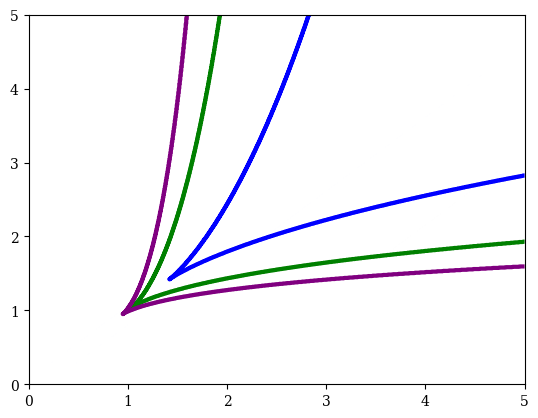

In [6]:
resolution = 1000
max_alpha = 5
alpha1_range = np.linspace(0, max_alpha, resolution)
alpha2_range = np.linspace(0, max_alpha, resolution)

bimaps = []
for idx, n in enumerate(tqdm(coop_levels,leave=True)):
    bistability_map = np.zeros((resolution, resolution))
    
    for i, a1 in enumerate(tqdm(alpha1_range,leave=False)):
        for j, a2 in enumerate(alpha2_range):
            
            # Smart guesses based on current alphas to find roots quickly
            
            n_guesses = 3

            x1s = np.linspace(0,5,801)
            err = np.abs(composite_eq(x1s,a1,a2,n))**2

            percentage_cutoff = 5
            thresh = np.percentile(err,percentage_cutoff)
            canidate_indices = np.where(err < thresh)

            kmeans = KMeans(n_clusters=n_guesses,random_state=67)
            kmeans.fit(x1s[canidate_indices].reshape(-1,1))

            # x1s[canidate_indices], len(x1s[canidate_indices]), 
            guesses = np.sort(kmeans.cluster_centers_.reshape(-1))

            roots = set()
            for g in guesses:
                try:
                    r, infodict, ier, msg = fsolve(composite_eq, g, args=(a1, a2, n), full_output=True)
                    if ier == 1 and r[0] >= 0:
                        roots.add(round(r[0], 3))
                except:
                    continue
            
            if len(roots) >= 3:
                bistability_map[j, i] = 1
    bimaps.append(bistability_map)

for idx,bimap in enumerate(bimaps):
    plt.contour(alpha1_range, alpha2_range, bimap, 
                levels=[0.5], colors=colors[idx], linewidths=3,zorder=1)

save_path =  f"resolution_{resolution}_bimaps.pkl"

with open(save_path, 'wb') as file:
    pickle.dump(bimaps,file)

In [17]:
resolution = 1000
max_alpha = 5
alpha1_range = np.linspace(0, max_alpha, resolution)
alpha2_range = np.linspace(0, max_alpha, resolution)

save_path = "resolution_1000_bimaps.pkl"

with open(save_path, 'rb') as file:
    bimaps = pickle.load(file)

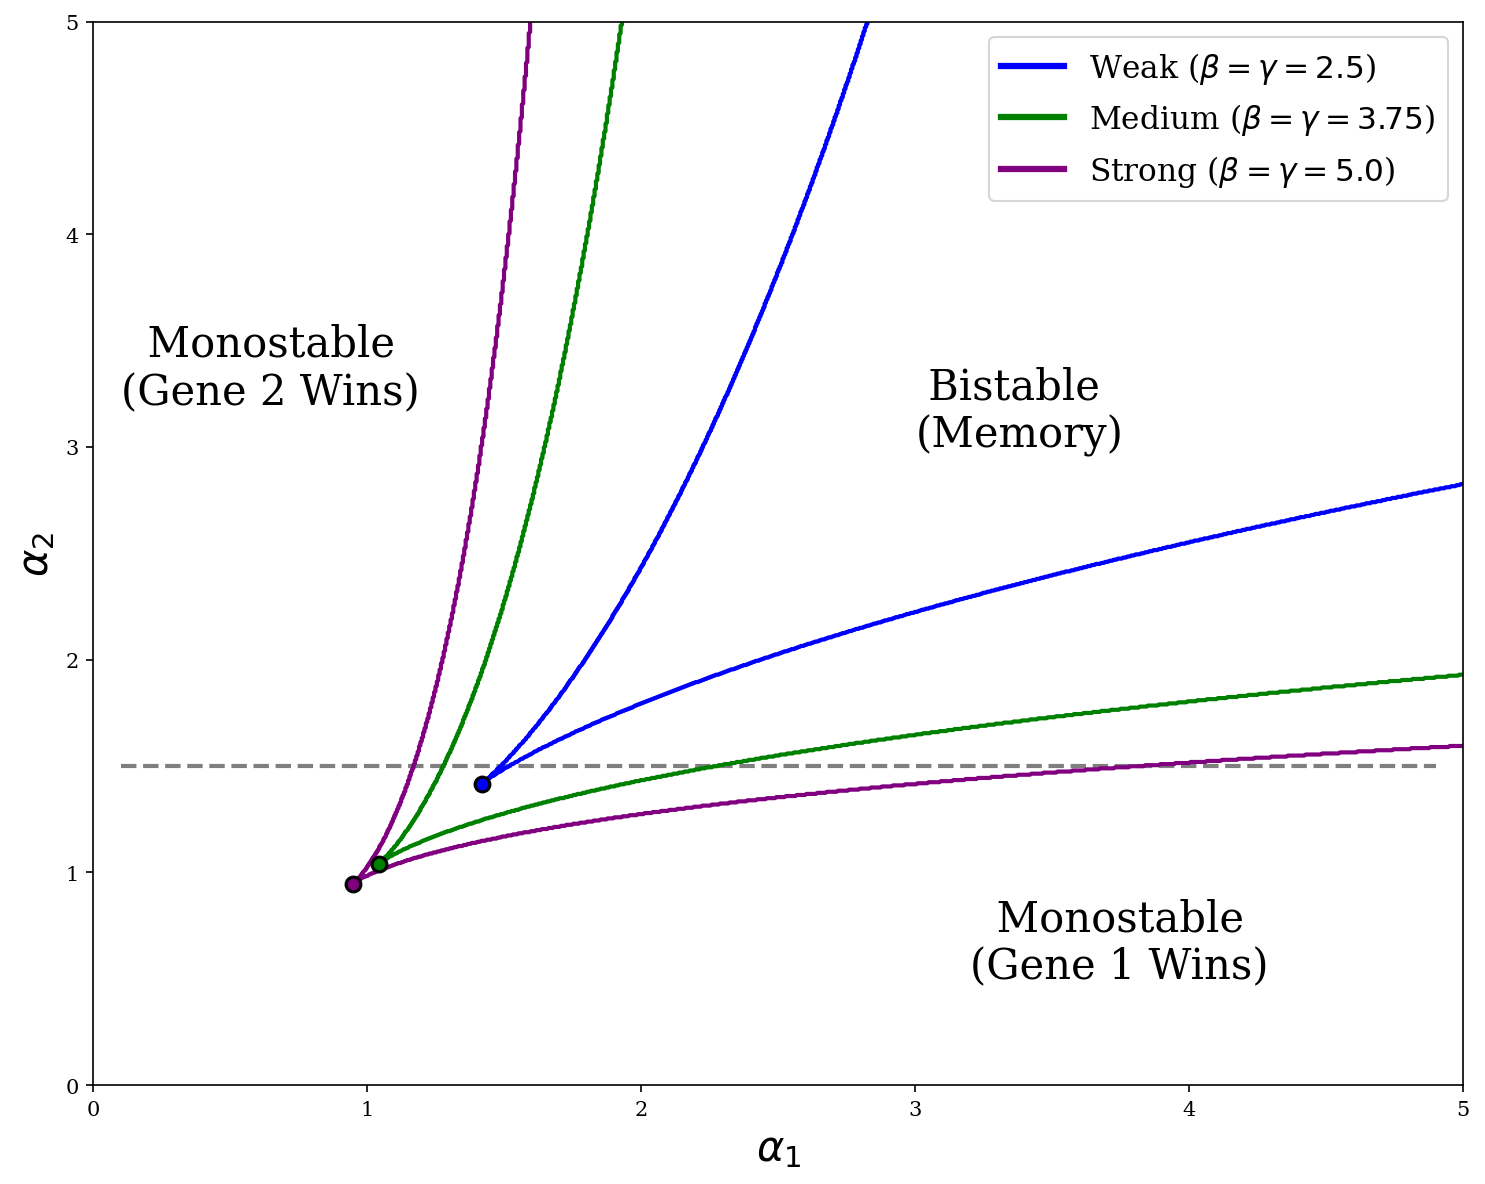

In [18]:
colors = ['blue','green', 'purple']
coop_levels = [2.5,3.75, 5.0] 

labels = [
    f'Weak ($\\beta=\\gamma={coop_levels[0]}$)',
    f'Medium ($\\beta=\\gamma={coop_levels[1]}$)',
    f'Strong ($\\beta=\\gamma={coop_levels[2]}$)']

plt.figure(figsize=(10,8),dpi=150)
for idx,bimap in enumerate(bimaps):
    plt.contour(alpha1_range, alpha2_range, bimap, 
                levels=[0.5], colors=colors[idx], linewidths=2,zorder=2)
    plt.plot([], [], color=colors[idx], linewidth=3, label=labels[idx])

    n = coop_levels[idx]
    alpha_c = n * (1 / (n-1))**(1+1/n)
    plt.scatter(
        alpha_c,
        alpha_c,
        c=colors[idx],
        marker='.',
        s=200,              # increase marker size
        edgecolors='black', # black outline
        linewidths=1.5,      # thickness of outline
        zorder=3

    )

plt.text(3,3," Bistable\n(Memory)",size=20)
plt.text(3.2,0.5,"  Monostable\n(Gene 1 Wins)",size=20)
plt.text(0.1,3.2,"  Monostable\n(Gene 2 Wins)",size=20)

plt.hlines(1.5,xmin=0.1,xmax=4.9,color='black', alpha=0.5,lw=2,linestyle='--',zorder=1)


plt.ylabel("$\\alpha_2$",size=20)
plt.xlabel("$\\alpha_1$",size=20)
plt.legend(fontsize=15)
plt.tight_layout()
plt.show()

## Hysteresis loops of learned model

In [19]:
from sklearn.cluster import KMeans
from scipy.optimize import root as sp_root
import pickle

In [20]:
alpha2=1.5

# beta and gamma
coop_levels = [2.5,3.75,5]

resolution = 2001
n_guesses = 40
atol = 1e-3

alpha1s = np.linspace(0.1, 5,resolution)

solution_paths = []

x_vals_yup = np.linspace(-.1, 5, 501)
y_vals_yup = np.linspace(-0.1, 5, 501)

X1s, X2s= np.meshgrid(x_vals_yup,y_vals_yup)

X12s = np.vstack((X1s.reshape(-1),X2s.reshape(-1))).T
X12s = torch.tensor(X12s,dtype=torch.float32)

# replace with loop
for coop_level in tqdm(coop_levels,leave=True):
    solutions = []
    for alpha1 in tqdm(alpha1s,leave=False):

        def objective(x):
            x_torch = torch.tensor(x,dtype=torch.float32)
            u_torch = torch.tensor([alpha1,alpha2,coop_level,coop_level],dtype=torch.float32)
            with torch.no_grad():
                g_out = g(x_torch,u_torch)
            diff = x_torch - g_out
            return diff.numpy()

        U = torch.tensor(
            [[alpha1,alpha2,coop_level,coop_level]],dtype=torch.float32
        ).expand(len(X12s),-1)

        with torch.no_grad():
            err = torch.linalg.norm(X12s - g(X12s,U),axis=1)**2

        percentage_cutoff = 5
        thresh = np.percentile(err,percentage_cutoff)
        canidate_indices = np.where(err < thresh)

        kmeans = KMeans(n_clusters=n_guesses,random_state=67)
        kmeans.fit(X12s[canidate_indices].numpy())
        guesses = kmeans.cluster_centers_

        roots = []
        for guess in guesses:
            sol = sp_root(objective, guess)
            if sol.success:
                roots.append(sol.x)
            
        unique_roots = []

        for r in roots:
            # If this root is not close to any root we've already saved
            if not any(np.allclose(r, existing, atol=atol) for existing in unique_roots):
                unique_roots.append(r)
        # if len(unique_roots) == 3:
        #     unique_roots
        solutions.append(unique_roots)

    path = f"resolution_{resolution}_coop_level_{coop_level}_model_solutions.pkl"
    solution_paths.append(path)

    with open(path, 'wb') as file:
        pickle.dump(solutions,file)

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/2001 [00:00<?, ?it/s]

  0%|          | 0/2001 [00:00<?, ?it/s]

  0%|          | 0/2001 [00:00<?, ?it/s]

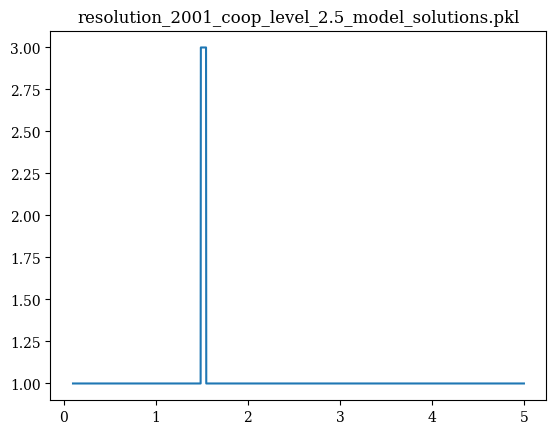

resolution_2001_coop_level_3.75_model_solutions.pkl yes 907


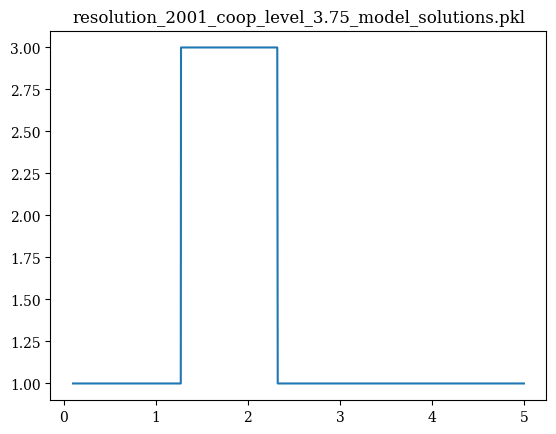

resolution_2001_coop_level_5_model_solutions.pkl yes 1526
resolution_2001_coop_level_5_model_solutions.pkl yes 1527


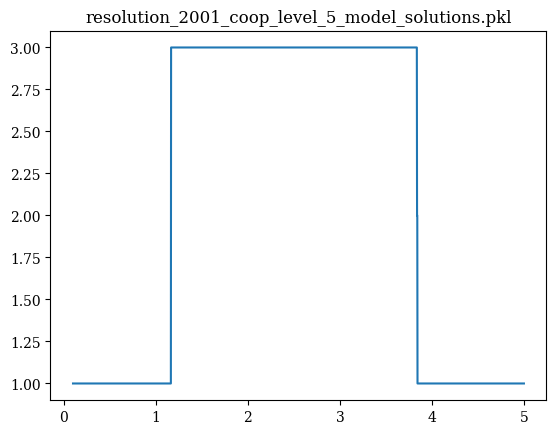

In [21]:
solution_paths = [
    "resolution_2001_coop_level_2.5_model_solutions.pkl",
    "resolution_2001_coop_level_3.75_model_solutions.pkl",
    "resolution_2001_coop_level_5_model_solutions.pkl",

]
# alpha1s= np.linspace(0,5,501)
for path in solution_paths:
    with open(path, 'rb') as file:
        solutions = pickle.load(file)
    num_sols = []
    for idx, roots in enumerate(solutions):
        num_sols.append(len(roots))
        if len(roots) == 2:
            print(path, "yes",idx)
    plt.plot(alpha1s,num_sols)  
    plt.title(path)
    plt.show()

In [22]:
def process_solutions(solutions):
    x11 = []
    x12 = []
    x13 = []

    x21 = []
    x22 = []
    x23 = []

    bifur = False
    bifur_indices = []
    for idx, sol in enumerate(solutions):
        if len(sol) == 3:
            sol = np.array(sol)
            x1s_ = np.sort(sol[:,0])
            x2s_ = np.sort(sol[:,1])

            x11.append(x1s_[0])
            x12.append(x1s_[1])
            x13.append(x1s_[2])

            x21.append(x2s_[2])
            x22.append(x2s_[1])
            x23.append(x2s_[0])
            bifur = True
            bifur_indices.append(idx)
            # print('test')

        elif len(sol) == 2 and bifur:
            # print('first flag')
            sol = np.array(sol)
            x1s_ = np.sort(sol[:,0])
            x2s_ = np.sort(sol[:,1])

            x13.append(x1s_[-1])
            # print('flag 1')
            # print(x1s_)
            x23.append(x2s_[0])

        elif len(sol) == 2 and (not bifur):
            # print('second flag')
            sol = np.array(sol)
            x1s_ = np.sort(sol[:,0])
            x2s_ = np.sort(sol[:,1])

            x11.append(x1s_[0])
            # print('flag2')
            # print(x1s_[0])

            x21.append(x2s_[1])


        elif bifur:
            x13.append(sol[0][0])
            x23.append(sol[0][1])
        else:
            x11.append(sol[0][0])
            x21.append(sol[0][1])
        
    stab1_indices = [i for i in range(0,bifur_indices[-1]+1)]
    stab2_indices = [i for i in range(bifur_indices[0], len(solutions))]

    indices = [stab1_indices, bifur_indices, stab2_indices]
    X1 = [x11,x12,x13]
    X2 = [x21,x22,x23]

    return X1, X2, indices




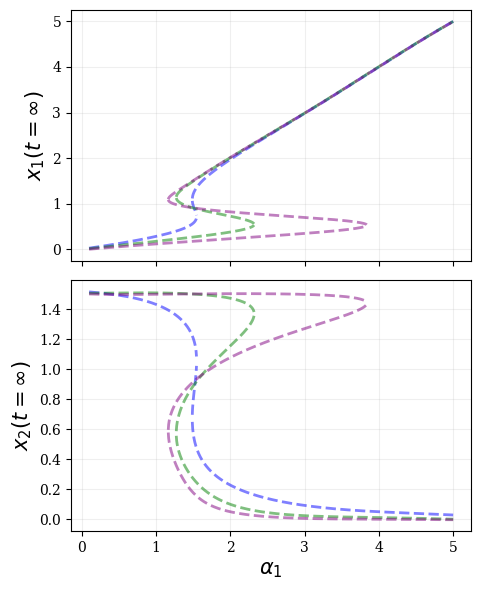

In [24]:
dpi = 100
lw = 2
alpha = 0.5


fig, axs = plt.subplots(2,1,figsize=(5,6),sharey=False,sharex=True,dpi=dpi)
axs = axs.flatten()

ax = axs[0]
ax.set_ylabel(r"$x_1(t=\infty)$",size=15,)
ax.grid(True, alpha=0.2)

ax = axs[1]
ax.set_ylabel(r"$x_2(t=\infty)$",size=15)
ax.set_xlabel(r"$\alpha_1$",size=15)
ax.grid(True, alpha=0.2)


for idx, path in enumerate(solution_paths):
    with open(path, 'rb') as file:
        solutions = pickle.load(file)

    x1_star, x2_star, ins = process_solutions(solutions)
    for x1_star_i,x2_star_i,alpha_idx_i in zip(x1_star, x2_star, ins):
        ax = axs[0]
        ax.plot(alpha1s[alpha_idx_i],x1_star_i,c=colors[idx],linestyle='--',lw=lw,alpha=alpha)
        ax = axs[1]
        plt.plot(alpha1s[alpha_idx_i],x2_star_i,c=colors[idx],linestyle='--',lw=lw,alpha=alpha)

# plt.grid(True, alpha=0.2)
plt.tight_layout()

## True Model

In [25]:
def genetic_toggle_switch(state, t, alpha1, alpha2, beta, gamma):
    """
    Computes derivatives for Equation 27 (Li & Lin, 2013).
    """
    x1, x2 = state
    # Note: In this symmetric simulation, alpha1=alpha2 and beta=gamma
    dx1dt = -x1 + alpha1 / (1 + x2**beta)
    dx2dt = -x2 + alpha2 / (1 + x1**gamma)
    return [dx1dt, dx2dt]

In [26]:
alpha2=1.5
atol = 1e-4
resolution = 2001
# beta and gamma - sym case

coop_levels = [2.5,3.75,5]

alpha1s = np.linspace(0.1, 5,resolution)

x_vals_yup = np.linspace(0.01, 5, 501)
y_vals_yup = np.linspace(0.01, 5, 501)

X1s, X2s= np.meshgrid(x_vals_yup,y_vals_yup)
X12s = np.vstack((X1s.reshape(-1),X2s.reshape(-1))).T

for coop_level in tqdm(coop_levels):

    beta = coop_level
    gamma = coop_level

    solutions_true = []
    for alpha1 in tqdm(alpha1s,leave=False):
        def objective(x):
            return np.array(genetic_toggle_switch(
                state=x,t=None,alpha1=alpha1,alpha2=alpha2,beta=beta,gamma=gamma
            ))




        dX1, dX2 = genetic_toggle_switch([X12s[:,0],X12s[:,1]],t=None,alpha1=alpha1,alpha2=alpha2,beta=beta,gamma=gamma)

        err = np.sqrt(dX1**2 + dX2**2)

        percentage_cutoff = 0.05
        thresh = np.percentile(err,percentage_cutoff)
        canidate_indices = np.where(err < thresh)

        initial_guesses = X12s[canidate_indices]

        roots = []
        for guess in initial_guesses:
            sol = sp_root(objective, guess)
            if sol.success:
                roots.append(sol.x)

        unique_roots = []
        for r in roots:
            # If this root is not close to any root we've already saved
            if not any(np.allclose(r, existing, atol=atol) for existing in unique_roots):
                unique_roots.append(r)
        solutions_true.append(unique_roots)

    path = f"resolution_{resolution}_coop_level_{coop_level}_true_solutions.pkl"
    with open(path,'wb') as file:
        pickle.dump(solutions_true,file)

    



  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/2001 [00:00<?, ?it/s]

/var/folders/9x/8bf0hckd1b122g3zlj_z9c1w0000gp/T/ipykernel_2993/2751216509.py:8: RuntimeWarning: invalid value encountered in scalar power
  dx2dt = -x2 + alpha2 / (1 + x1**gamma)
/var/folders/9x/8bf0hckd1b122g3zlj_z9c1w0000gp/T/ipykernel_2993/2751216509.py:7: RuntimeWarning: invalid value encountered in scalar power
  dx1dt = -x1 + alpha1 / (1 + x2**beta)


  0%|          | 0/2001 [00:00<?, ?it/s]

  0%|          | 0/2001 [00:00<?, ?it/s]

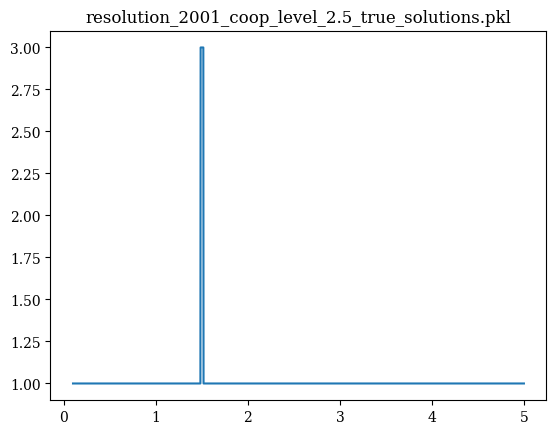

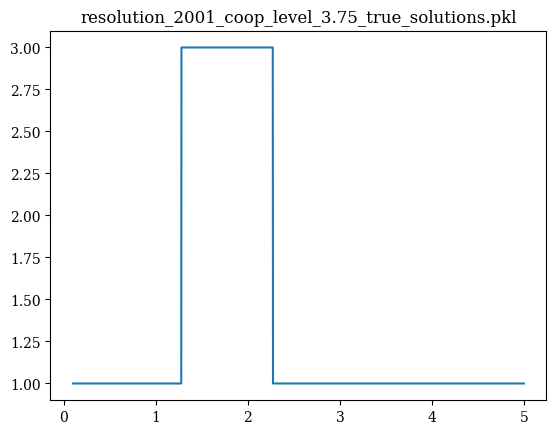

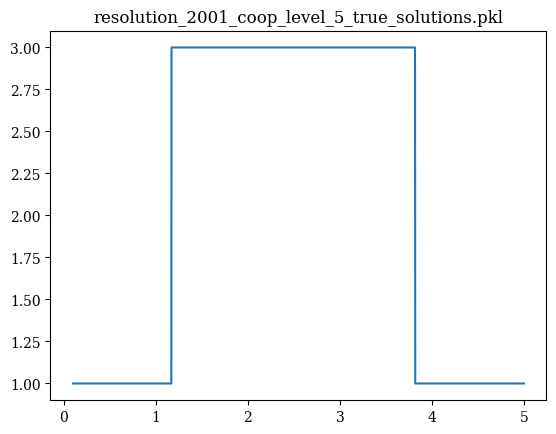

In [27]:
true_solution_paths = [
    "resolution_2001_coop_level_2.5_true_solutions.pkl",
    "resolution_2001_coop_level_3.75_true_solutions.pkl",
    "resolution_2001_coop_level_5_true_solutions.pkl",

]

for path in true_solution_paths:
    with open(path, 'rb') as file:
        solutions = pickle.load(file)
    num_sols = []
    for idx, roots in enumerate(solutions):
        num_sols.append(len(roots))
        if len(roots) == 2:
            print(path, "yes",idx)
    plt.plot(alpha1s,num_sols)  
    plt.title(path)
    plt.show()

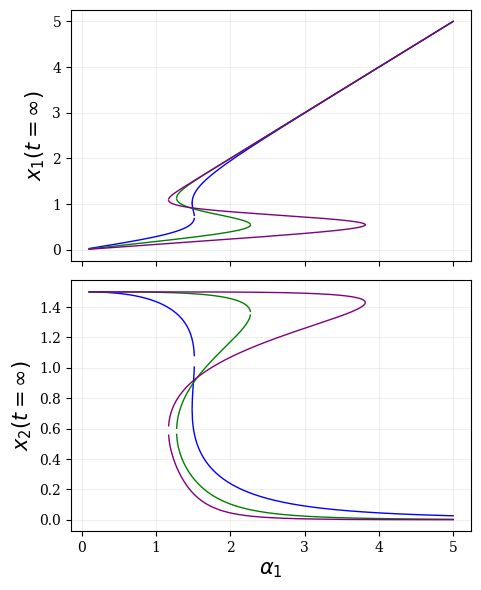

In [28]:
dpi = 100
lw = 1
alpha = 1

fig, axs = plt.subplots(2,1,figsize=(5,6),sharey=False,sharex=True,dpi=dpi)
axs = axs.flatten()

ax = axs[0]
ax.set_ylabel(r"$x_1(t=\infty)$",size=15,)
ax.grid(True, alpha=0.2)

ax = axs[1]
ax.set_ylabel(r"$x_2(t=\infty)$",size=15)
ax.set_xlabel(r"$\alpha_1$",size=15)
ax.grid(True, alpha=0.2)


for idx, path in enumerate(true_solution_paths):
    with open(path, 'rb') as file:
        solutions = pickle.load(file)

    x1_star, x2_star, ins = process_solutions(solutions)
    for x1_star_i,x2_star_i,alpha_idx_i in zip(x1_star, x2_star, ins):
        ax = axs[0]
        ax.plot(alpha1s[alpha_idx_i],x1_star_i,c=colors[idx],linestyle='-',lw=lw,alpha=alpha)
        ax = axs[1]
        plt.plot(alpha1s[alpha_idx_i],x2_star_i,c=colors[idx],linestyle='-',lw=lw,alpha=alpha)

# plt.grid(True, alpha=0.2)
plt.tight_layout()

# Plot true and model bifurs

In [ ]:
# solution_paths = [
#     "resolution_2001_coop_level_2.5_deep_model_solutions.pkl",
#     "resolution_2001_coop_level_3.75_deep_model_solutions.pkl",
#     "resolution_2001_coop_level_5_deep_model_solutions.pkl",

# ]

# true_solution_paths = [
#     "resolution_2001_coop_level_2.5_true_solutions.pkl",
#     "resolution_2001_coop_level_3.75_true_solutions.pkl",
#     "resolution_2001_coop_level_5_true_solutions.pkl",

# ]


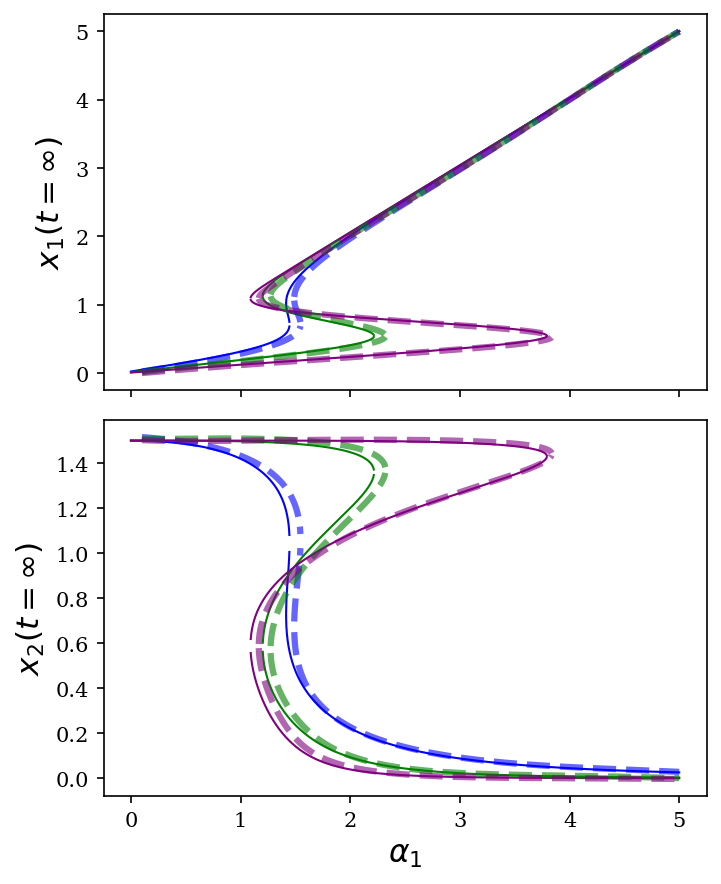

In [29]:
dpi = 150
lw = 3
alpha = 0.6
zorder = 2

lw_true = 1
alpha_true = 1
zorder_true = 1

colors = ['blue', 'green','purple']

fig, axs = plt.subplots(2,1,figsize=(5,6),sharey=False,sharex=True,dpi=dpi)
axs = axs.flatten()

ax = axs[0]
ax.set_ylabel(r"$x_1(t=\infty)$",size=15,)
# ax.grid(True, alpha=0.2)

ax = axs[1]
ax.set_ylabel(r"$x_2(t=\infty)$",size=15)
ax.set_xlabel(r"$\alpha_1$",size=15)
# ax.grid(True, alpha=0.2)


for idx, path in enumerate(solution_paths):
    with open(path, 'rb') as file:
        solutions = pickle.load(file)

    x1_star, x2_star, ins = process_solutions(solutions)
    for x1_star_i,x2_star_i,alpha_idx_i in zip(x1_star, x2_star, ins):
        ax = axs[0]
        ax.plot(
            alpha1s[alpha_idx_i],x1_star_i,
            c=colors[idx],linestyle='--',lw=lw,alpha=alpha,zorder=zorder)
        ax = axs[1]
        plt.plot(
            alpha1s[alpha_idx_i],x2_star_i,
            c=colors[idx],linestyle='--',lw=lw,alpha=alpha,zorder=zorder)

# colors = ['black']*3
alpha1s = np.linspace(0,5,2001)
for idx, path in enumerate(true_solution_paths):
    with open(path, 'rb') as file:
        solutions = pickle.load(file)

    x1_star, x2_star, ins = process_solutions(solutions)
    for x1_star_i,x2_star_i,alpha_idx_i in zip(x1_star, x2_star, ins):
        ax = axs[0]
        ax.plot(
            alpha1s[alpha_idx_i],x1_star_i,
            c=colors[idx],linestyle='-',lw=lw_true,alpha=alpha_true,zorder=zorder_true)
        ax = axs[1]
        plt.plot(
            alpha1s[alpha_idx_i],x2_star_i,
            c=colors[idx],linestyle='-',lw=lw_true,alpha=alpha_true,zorder=zorder_true)

# plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# Composite Figure

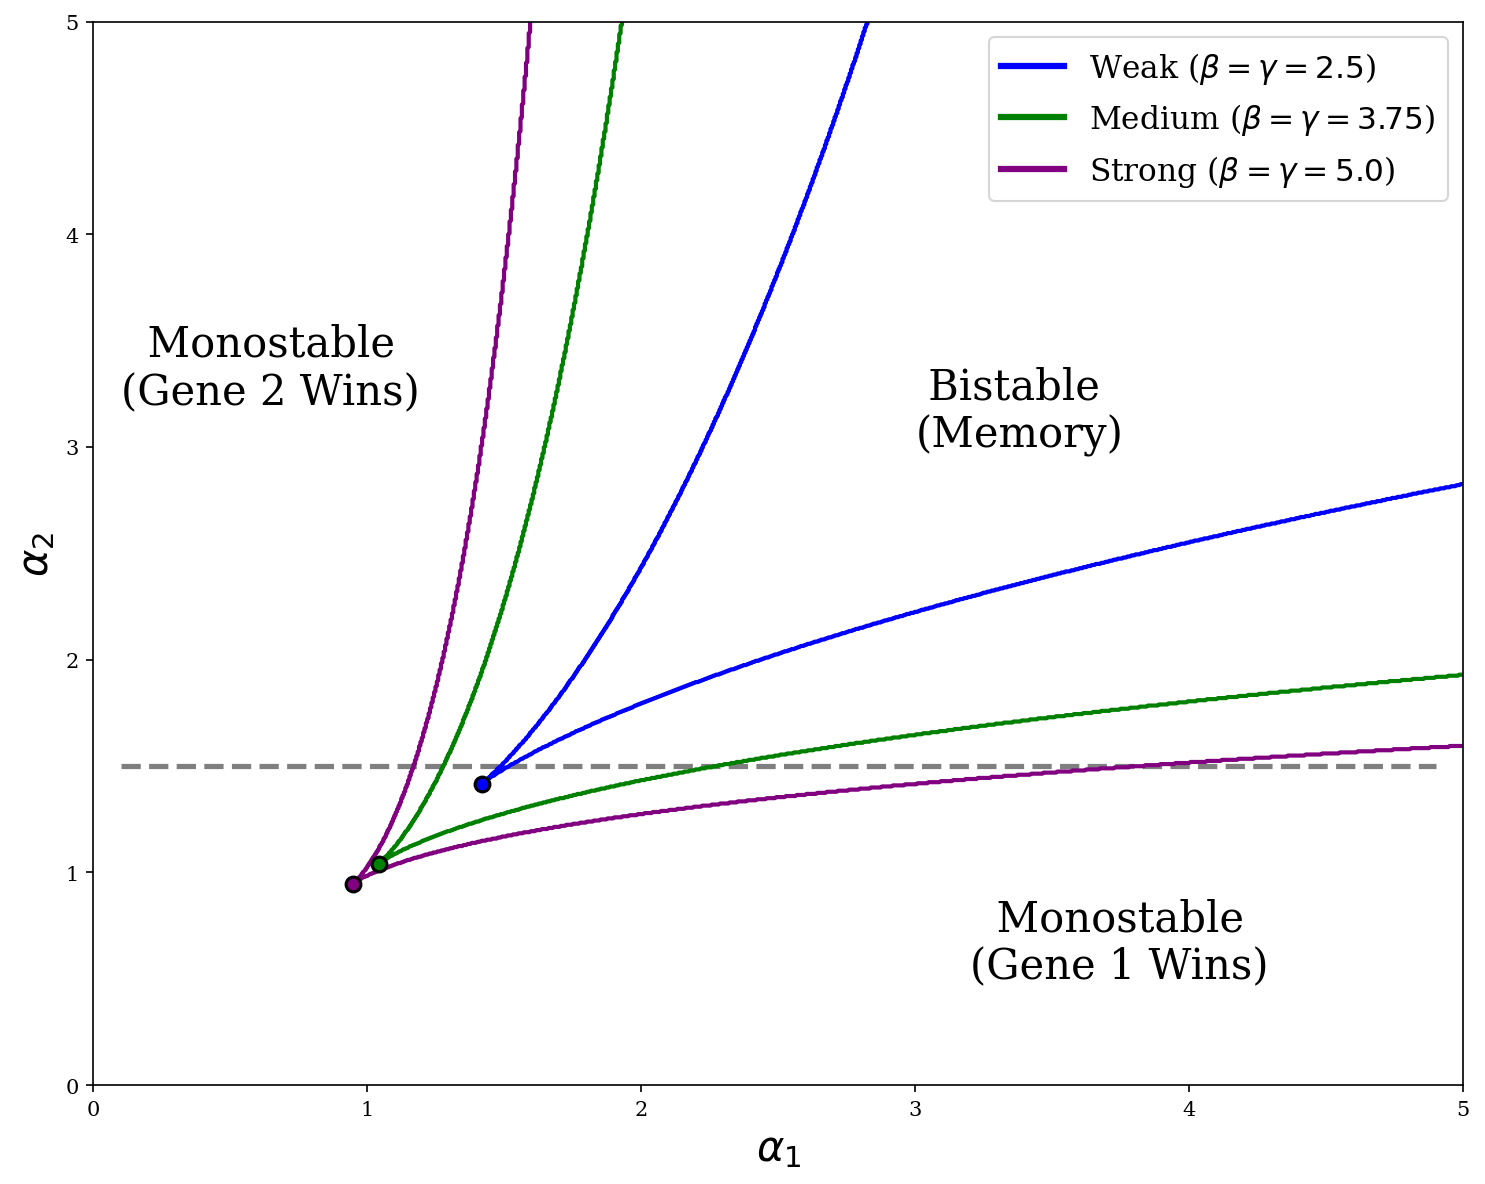

In [30]:
resolution = 1000
max_alpha = 5
alpha1_range = np.linspace(0, max_alpha, resolution)
alpha2_range = np.linspace(0, max_alpha, resolution)

save_path = "resolution_1000_bimaps.pkl"

with open(save_path, 'rb') as file:
    bimaps = pickle.load(file)



colors = ['blue','green', 'purple']
coop_levels = [2.5,3.75, 5.0] 

labels = [
    f'Weak ($\\beta=\\gamma={coop_levels[0]}$)',
    f'Medium ($\\beta=\\gamma={coop_levels[1]}$)',
    f'Strong ($\\beta=\\gamma={coop_levels[2]}$)']

plt.figure(figsize=(10,8),dpi=150)
for idx,bimap in enumerate(bimaps):
    plt.contour(alpha1_range, alpha2_range, bimap, 
                levels=[0.5], colors=colors[idx], linewidths=2,zorder=2)
    plt.plot([], [], color=colors[idx], linewidth=3, label=labels[idx])

    n = coop_levels[idx]
    alpha_c = n * (1 / (n-1))**(1+1/n)
    plt.scatter(
        alpha_c,
        alpha_c,
        c=colors[idx],
        marker='.',
        s=200,              # increase marker size
        edgecolors='black', # black outline
        linewidths=1.5,      # thickness of outline
        zorder=3

    )

plt.text(3,3," Bistable\n(Memory)",size=20)
plt.text(3.2,0.5,"  Monostable\n(Gene 1 Wins)",size=20)
plt.text(0.1,3.2,"  Monostable\n(Gene 2 Wins)",size=20)

plt.hlines(1.5,xmin=0.1,xmax=4.9,color='black', alpha=0.5,lw=2.5,linestyle='--',zorder=1)
plt.ylabel("$\\alpha_2$",size=20)
plt.xlabel("$\\alpha_1$",size=20)
plt.legend(fontsize=15)
plt.tight_layout()
plt.show()

In [31]:
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerTuple
from matplotlib.legend_handler import HandlerBase

class VerticalStackHandler(HandlerBase):
    def __init__(self, spacing_factor=0.35, y_offset=-20, **kwargs):
        """
        spacing_factor: Gap between lines relative to font size.
        y_offset: Vertical shift relative to font size (negative moves stack DOWN).
        """
        self.spacing_factor = spacing_factor
        self.y_offset = y_offset
        super().__init__(**kwargs)

    def legend_artist(self, legend, orig_handle, fontsize, handlebox):
        x0, y0 = handlebox.xdescent, handlebox.ydescent
        width, height = handlebox.width, handlebox.height
        
        lines = orig_handle
        num_lines = len(lines)
        
        # 1. Calculate the center, then Apply the Manual Offset
        #    (y_offset * fontsize) lets you shift it in consistent units
        yc = (y0 + height / 2) + (self.y_offset * fontsize)
        
        # 2. Calculate spacing
        spacing = fontsize * self.spacing_factor
        
        # 3. Create vertical offsets relative to the center
        #    This keeps the group centered on 'yc'
        offsets = [(i - (num_lines - 1) / 2) * spacing for i in range(num_lines)]
        
        for line, offset in zip(lines, offsets):
            leg_line = Line2D(
                [x0, x0 + width],
                [yc + offset, yc + offset], 
                color=line.get_color(),
                linestyle=line.get_linestyle(),
                linewidth=line.get_linewidth(),
                alpha=line.get_alpha(),
                transform=handlebox.get_transform()
            )
            handlebox.add_artist(leg_line)
            
        return lines

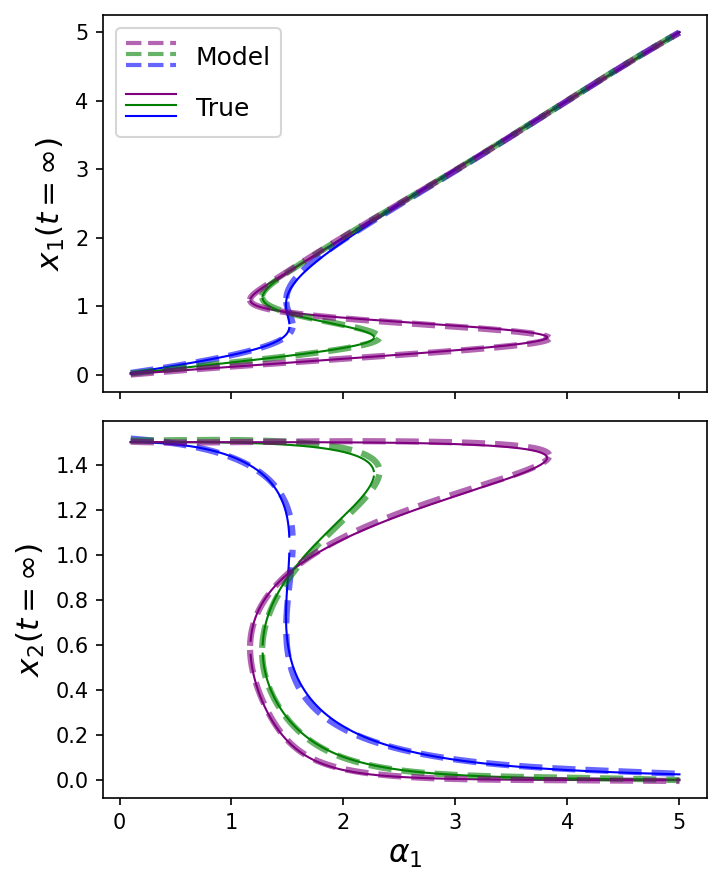

In [36]:
solution_paths = [
    "resolution_2001_coop_level_2.5_model_solutions.pkl",
    "resolution_2001_coop_level_3.75_model_solutions.pkl",
    "resolution_2001_coop_level_5_model_solutions.pkl",

]

true_solution_paths = [
    "resolution_2001_coop_level_2.5_true_solutions.pkl",
    "resolution_2001_coop_level_3.75_true_solutions.pkl",
    "resolution_2001_coop_level_5_true_solutions.pkl",

]

dpi = 150
lw = 3
alpha = 0.6
zorder = 2

lw_true = 1
alpha_true = 1
zorder_true = 1

colors = ['blue', 'green','purple']

fig, axs = plt.subplots(2,1,figsize=(5,6),sharey=False,sharex=True,dpi=dpi)
axs = axs.flatten()

ax = axs[0]
ax.set_ylabel(r"$x_1(t=\infty)$",size=15,)
# ax.grid(True, alpha=0.2)

ax = axs[1]
ax.set_ylabel(r"$x_2(t=\infty)$",size=15)
ax.set_xlabel(r"$\alpha_1$",size=15)
# ax.grid(True, alpha=0.2)


for idx, path in enumerate(solution_paths):
    with open(path, 'rb') as file:
        solutions = pickle.load(file)

    x1_star, x2_star, ins = process_solutions(solutions)
    for x1_star_i,x2_star_i,alpha_idx_i in zip(x1_star, x2_star, ins):
        ax = axs[0]
        ax.plot(
            alpha1s[alpha_idx_i],x1_star_i,
            c=colors[idx],linestyle='--',lw=lw,alpha=alpha,zorder=zorder)
        ax = axs[1]
        plt.plot(
            alpha1s[alpha_idx_i],x2_star_i,
            c=colors[idx],linestyle='--',lw=lw,alpha=alpha,zorder=zorder)

# colors = ['black']*3
for idx, path in enumerate(true_solution_paths):
    with open(path, 'rb') as file:
        solutions = pickle.load(file)

    x1_star, x2_star, ins = process_solutions(solutions)
    for x1_star_i,x2_star_i,alpha_idx_i in zip(x1_star, x2_star, ins):
        ax = axs[0]
        ax.plot(
            alpha1s[alpha_idx_i],x1_star_i,
            c=colors[idx],linestyle='-',lw=lw_true,alpha=alpha_true,zorder=zorder_true)
        ax = axs[1]
        ax.plot(
            alpha1s[alpha_idx_i],x2_star_i,
            c=colors[idx],linestyle='-',lw=lw_true,alpha=alpha_true,zorder=zorder_true)




# Create handles (same as before)
lines_model = [
    Line2D([0], [0], color=c, linestyle='--', lw=2, alpha=alpha) 
    for c in colors
]
lines_true = [
    Line2D([0], [0], color=c, linestyle='-', lw=1, alpha=alpha_true) 
    for c in colors
]

axs[0].legend(
    handles=[tuple(lines_model), tuple(lines_true)],
    labels=['Model', 'True'],
    
    # --- TUNING SECTION ---
    # spacing_factor=0.35  -> Controls how "squeezed" the burger is
    # y_offset=-0.4        -> MOVES THE WHOLE STACK DOWN (Adjust this value!)
    handler_map={tuple: VerticalStackHandler(spacing_factor=0.45, y_offset=-0.8)}, 
    
    handleheight=2,  # Gives the box enough height so lines don't clip
    loc='best',
    fontsize=12,
    ncol=1
)


# plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# Composite Figure for Paper

In [33]:
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerTuple
from matplotlib.legend_handler import HandlerBase

class VerticalStackHandler(HandlerBase):
    def __init__(self, spacing_factor=0.35, y_offset=-20, **kwargs):
        """
        spacing_factor: Gap between lines relative to font size.
        y_offset: Vertical shift relative to font size (negative moves stack DOWN).
        """
        self.spacing_factor = spacing_factor
        self.y_offset = y_offset
        super().__init__(**kwargs)

    def legend_artist(self, legend, orig_handle, fontsize, handlebox):
        x0, y0 = handlebox.xdescent, handlebox.ydescent
        width, height = handlebox.width, handlebox.height
        
        lines = orig_handle
        num_lines = len(lines)
        
        # 1. Calculate the center, then Apply the Manual Offset
        #    (y_offset * fontsize) lets you shift it in consistent units
        yc = (y0 + height / 2) + (self.y_offset * fontsize)
        
        # 2. Calculate spacing
        spacing = fontsize * self.spacing_factor
        
        # 3. Create vertical offsets relative to the center
        #    This keeps the group centered on 'yc'
        offsets = [(i - (num_lines - 1) / 2) * spacing for i in range(num_lines)]
        
        for line, offset in zip(lines, offsets):
            leg_line = Line2D(
                [x0, x0 + width],
                [yc + offset, yc + offset], 
                color=line.get_color(),
                linestyle=line.get_linestyle(),
                linewidth=line.get_linewidth(),
                alpha=line.get_alpha(),
                transform=handlebox.get_transform()
            )
            handlebox.add_artist(leg_line)
            
        return lines

In [62]:
savefig=True

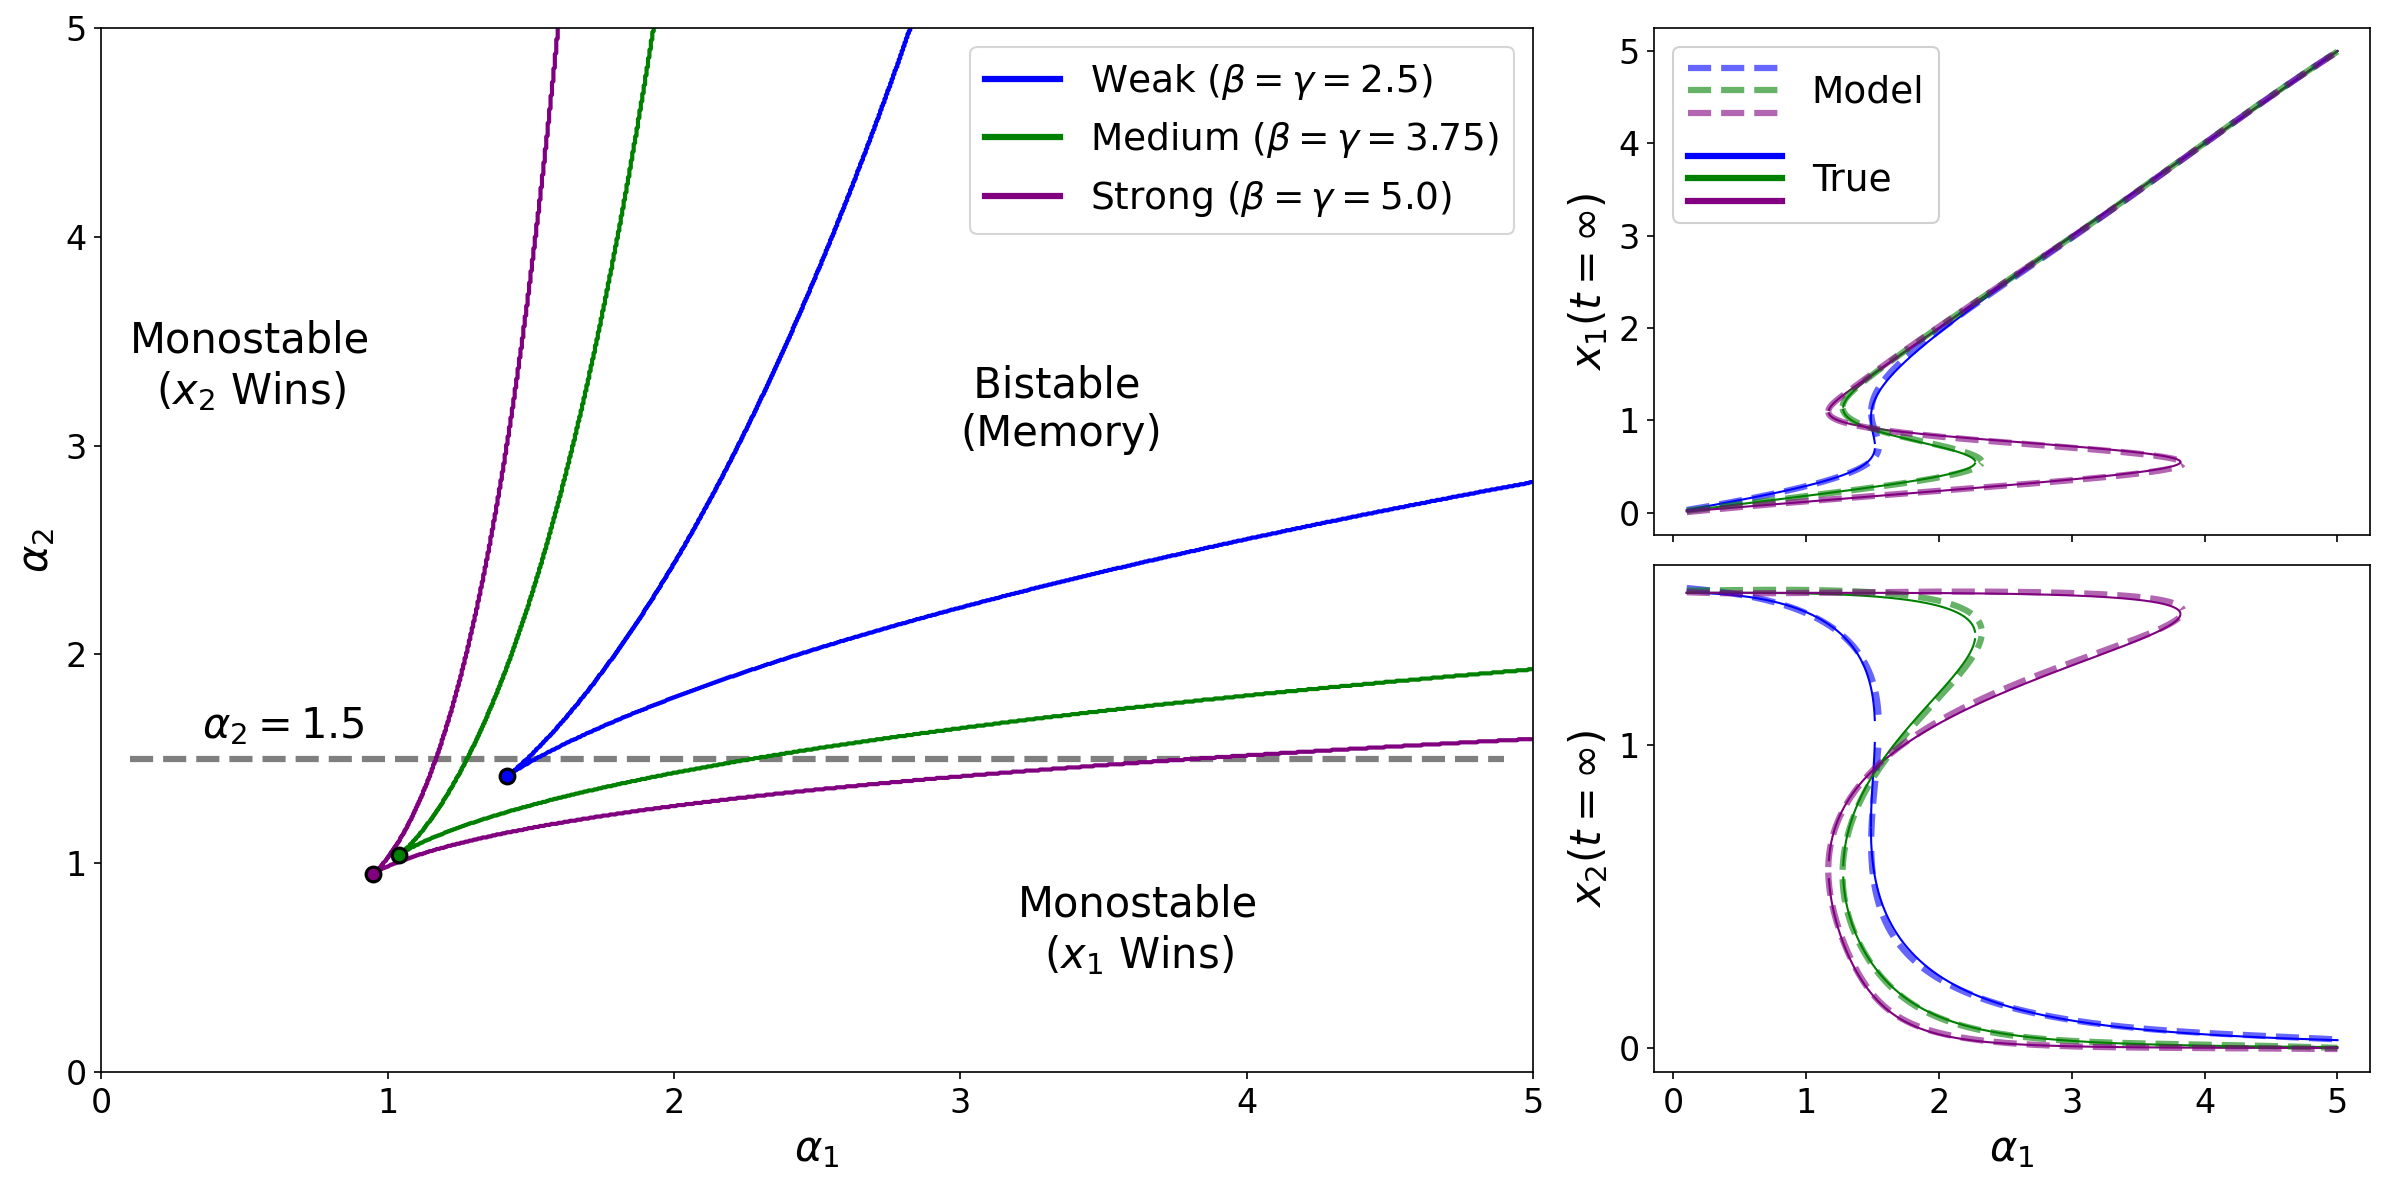

In [63]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pickle
plt.style.use('default')



# Shared configurations
colors = ['blue', 'green', 'purple']
dpi = 150

# --- Left Plot Config ---
# left plot config
resolution = 1000
max_alpha = 5
alpha1_range = np.linspace(0, max_alpha, resolution)
alpha2_range = np.linspace(0, max_alpha, resolution)
coop_levels = [2.5, 3.75, 5.0]
labels = [
    f'Weak ($\\beta=\\gamma={coop_levels[0]}$)',
    f'Medium ($\\beta=\\gamma={coop_levels[1]}$)',
    f'Strong ($\\beta=\\gamma={coop_levels[2]}$)'
]
left_save_path = "resolution_1000_bimaps.pkl"


resolution = 2001
alpha1s = np.linspace(0.1, 5,resolution)

solution_paths = [
    "resolution_2001_coop_level_2.5_model_solutions.pkl",
    "resolution_2001_coop_level_3.75_model_solutions.pkl",
    "resolution_2001_coop_level_5_model_solutions.pkl",
]
true_solution_paths = [
    "resolution_2001_coop_level_2.5_true_solutions.pkl",
    "resolution_2001_coop_level_3.75_true_solutions.pkl",
    "resolution_2001_coop_level_5_true_solutions.pkl",
]
lw = 3
alpha_val = 0.6
zorder_val = 2
lw_true = 1
alpha_true = 1
zorder_true = 1


with open(left_save_path, 'rb') as file:
    bimaps = pickle.load(file)

# Figure Initialization 
fig = plt.figure(figsize=(16, 8), dpi=dpi)

gs = gridspec.GridSpec(2, 2, width_ratios=[2, 1], height_ratios=[1, 1], figure=fig)

# Create the Axes
ax_left = fig.add_subplot(gs[:, 0])      
ax_right_top = fig.add_subplot(gs[0, 1]) 
ax_right_bot = fig.add_subplot(gs[1, 1], sharex=ax_right_top)

for idx, bimap in enumerate(bimaps):
    # Use ax_left instead of plt
    ax_left.contour(alpha1_range, alpha2_range, bimap, 
                levels=[0.5], colors=colors[idx], linewidths=2, zorder=2)

    ax_left.plot([], [], color=colors[idx], linewidth=3, label=labels[idx])

    n = coop_levels[idx]
    alpha_c = n * (1 / (n-1))**(1+1/n)
    
    ax_left.scatter(
        alpha_c, alpha_c,
        c=colors[idx], marker='.', s=200,
        edgecolors='black', linewidths=1.5, zorder=3
    )


ax_left.text(3, 3, " Bistable\n(Memory)", size=20)
ax_left.text(3.2, 0.5, "Monostable\n"+r"  ($x_1$ Wins)", size=20)
ax_left.text(0.1, 3.2, "Monostable\n"+r"  ($x_2$ Wins)", size=20)
ax_left.text(0.35, 1.6, r"$\alpha_2 = 1.5$", size=20)


ax_left.hlines(1.5, xmin=0.1, xmax=4.9, color='black', alpha=0.5, lw=3, linestyle='--', zorder=1)

ax_left.set_ylabel("$\\alpha_2$", size=20)
ax_left.set_xlabel("$\\alpha_1$", size=20)
# ax_left.legend(fontsize=18, loc='upper left',handlelength=2.5)
ax_left.legend(fontsize=18, ncol=1,bbox_to_anchor=(1,1))




ax_right_top.set_ylabel(r"$x_1(t=\infty)$", size=20)

ax_right_bot.set_ylabel(r"$x_2(t=\infty)$", size=20)
ax_right_bot.set_xlabel(r"$\alpha_1$", size=20)

ax_right_bot.set_yticks([0 ,1])

plt.setp(ax_right_top.get_xticklabels(), visible=False)

# Loop 1: Model Solutions
for idx, path in enumerate(solution_paths):
    try:
        with open(path, 'rb') as file:
            solutions = pickle.load(file)
            
        # Assuming process_solutions and alpha1s exist in your environment
        x1_star, x2_star, ins = process_solutions(solutions)
        
        for x1_star_i, x2_star_i, alpha_idx_i in zip(x1_star, x2_star, ins):
            # Plot on Top Right
            ax_right_top.plot(
                alpha1s[alpha_idx_i], x1_star_i,
                c=colors[idx], linestyle='--', lw=lw, alpha=alpha_val, zorder=zorder_val
            )
            # Plot on Bottom Right
            ax_right_bot.plot(
                alpha1s[alpha_idx_i], x2_star_i,
                c=colors[idx], linestyle='--', lw=lw, alpha=alpha_val, zorder=zorder_val
            )
    except (FileNotFoundError, NameError):
        pass # Skip if files or functions are missing for this demo

# Loop 2: True Solutions
for idx, path in enumerate(true_solution_paths):
    try:
        with open(path, 'rb') as file:
            solutions = pickle.load(file)

        x1_star, x2_star, ins = process_solutions(solutions)
        
        for x1_star_i, x2_star_i, alpha_idx_i in zip(x1_star, x2_star, ins):
            # Plot on Top Right
            ax_right_top.plot(
                alpha1s[alpha_idx_i], x1_star_i,
                c=colors[idx], linestyle='-', lw=lw_true, alpha=alpha_true, zorder=zorder_true
            )
            # Plot on Bottom Right
            ax_right_bot.plot(
                alpha1s[alpha_idx_i], x2_star_i,
                c=colors[idx], linestyle='-', lw=lw_true, alpha=alpha_true, zorder=zorder_true
            )
    except (FileNotFoundError, NameError):
        pass

# tick sizes
# Apply to a specific axis
tick_labelsize=16
ax_left.tick_params(axis='both', which='major', labelsize=tick_labelsize)
ax_right_top.tick_params(axis='both', which='major', labelsize=tick_labelsize)
ax_right_bot.tick_params(axis='both', which='major', labelsize=tick_labelsize)

# ax_right_top.text(4,0.5,r"$\alpha_2 = 1.5$",size=20)
# ax_right_top.set_title(r"$\alpha_2 = 1.5$",size=25)

# custom legend 
lines_model = [
    Line2D([0], [0], color=c, linestyle='--', lw=3, alpha=alpha) 
    for c in colors[::-1]
]
lines_true = [
    Line2D([0], [0], color=c, linestyle='-', lw=3, alpha=alpha_true) 
    for c in colors[::-1]
]

ax_right_top.legend(
    handles=[tuple(lines_model), tuple(lines_true)],
    labels=['Model', 'True'],
    

    handler_map={tuple: VerticalStackHandler(spacing_factor=0.6, y_offset=-0.9)}, 

    handleheight=2.,     
    handlelength=2.5,     
    borderpad=0.4,      
    labelspacing=0.8,
    handletextpad=0.8,    
    
    loc='upper left',    
    fontsize=18,
    ncol=1,
    framealpha=0.9        
)



plt.tight_layout()
if savefig: 
    plt.savefig("composite-toggle-switch.png")
plt.show()